<a href="https://colab.research.google.com/github/Vlasovasona/ML-home-works/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Создание тензоров в PyTorch


---





In [2]:
import torch
import numpy as np

np.set_printoptions(precision=3)
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)
t_a = torch.tensor(a)
t_b = torch.from_numpy(b)
print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


In [ ]:
t_ones = torch.ones(2, 3)
t_ones.shape

torch.Size([2, 3])

In [ ]:
rand_tensor = torch.rand(2, 3)
print(rand_tensor)

tensor([[0.2195, 0.0563, 0.8180],
        [0.8846, 0.2763, 0.2958]])


In [ ]:
# функция torch.to() можно использовать для
# изменения типа данных тензора на желаемый тип

t_a_new = t_a.to(torch.int64)
print(t_a_new.dtype)

torch.int64


In [ ]:
# транспонирование тензора

t = torch.rand(3, 5)
t_tr = torch.transpose(t, 0, 1)
print(t.shape, '-->', t_tr.shape)

torch.Size([3, 5]) --> torch.Size([5, 3])


In [ ]:
# изменение формы тензора (например, преобразование из одномерного вектора в
# двумерный массив)

t = torch.zeros(30)
t_reshaped = t.reshape(5, 6)
print(t_reshaped.shape)

torch.Size([5, 6])


In [ ]:
# удаление ненужных измерений (измерения с размером 1, которые не нужны)
t = torch.zeros(1, 2, 1, 4, 1)
t_sqz = torch.squeeze(t, 2)
print(t.shape, '-->', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1]) --> torch.Size([1, 2, 4, 1])


# Применение к тензорам математических операций.


---



In [ ]:
torch.manual_seed(1)
t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2))

Метод torch.rand возвращает тензор, заполненный случайными числами из равномерного распределения в диапазоне [0, 1).

In [ ]:
t3 = torch.multiply(t1, t2) # поэлементное умножение
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


In [ ]:
t4 = torch.mean(t1, axis=0) # среднее по осям
print(t4)

tensor([-0.1373,  0.2028])


In [ ]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))
print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


In [ ]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)
print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


In [ ]:
# torch.linalg.norm вычисление p-ой нормы тензора
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1) # вычисление 2 нормы
print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


# Разделение, стекирование и конкатенация тензоров


---



In [ ]:
torch.manual_seed(1)
t = torch.rand(6)
print(t)

t_splits = torch.chunk(t, 3) # делит входной тензор на список тензоров одинакового размера
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

In [ ]:
A = torch.ones(3)
B = torch.zeros(2)
C = torch.cat([A, B], axis=0) # объединение двух тензоров в одномерный тензор
print(C)

tensor([1., 1., 1., 0., 0.])


In [ ]:
A = torch.ones(3)
B = torch.zeros(3)
S = torch.stack([A, B], axis=1) # стекирование в двумерный тензор
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


# Построение конвейеров ввода в PyTorch


---



In [ ]:
from torch.utils.data import DataLoader
t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t) # загрузчик набора данных

for item in data_loader:
  print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [ ]:
# создание из исходного набора данных пакетов размером 3
# необязательный аргумент drop_last полезен в случаях, когда кол-во элементов
# в тензоре не кратно желаемому размеру пакета. Мы можем удалить последний
# неполный пакет, установив drop_last = True

data_loader = DataLoader(t, batch_size=3, drop_last=False)
for i, batch in enumerate(data_loader, 1):
  print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


In [ ]:
torch.manual_seed(1)
t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

In [10]:
from torch.utils.data import Dataset
class JoinDataset(Dataset):
  def __init__(self, x, y):
    self.x = x
    self.y = y

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

In [ ]:
from torch.utils.data import TensorDataset
joint_dataset = JoinDataset(t_x, t_y) # можно было TensorDataset

In [ ]:
for example in joint_dataset:
  print('x: ', example[0], ' y: ', example[1])

x:  tensor([0.7576, 0.2793, 0.4031])  y:  tensor(0)
x:  tensor([0.7347, 0.0293, 0.7999])  y:  tensor(1)
x:  tensor([0.3971, 0.7544, 0.5695])  y:  tensor(2)
x:  tensor([0.4388, 0.6387, 0.5247])  y:  tensor(3)


In [ ]:
torch.manual_seed(1)
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

In [ ]:
for i, batch in enumerate(data_loader):
  print(f'batch {i+1}:', 'x:', batch[0],
        '\n       y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
       y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
       y: tensor([1, 3])


In [ ]:
for epoch in range(2): # перемешиваем батчи в кажой эпохе, data_loader решает
  print(f'epoch {epoch+1}')
  for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}', 'x:', batch[0],
          '/n y:', batch[1])

epoch 1
batch 1 x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) /n y: tensor([0, 2])
batch 2 x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) /n y: tensor([1, 3])
epoch 2
batch 1 x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) /n y: tensor([3, 2])
batch 2 x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) /n y: tensor([0, 1])


# Работа с файлами, сохраненными на локальном диске


---



In [ ]:
!unzip cat_dog_images.zip

Archive:  cat_dog_images.zip
replace cat_dog_images/cat-01.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import pathlib
imgdir_path = pathlib.Path('/content/cat_dog_images')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])
print(file_list)

['/content/cat_dog_images/cat-01.jpg', '/content/cat_dog_images/cat-02.jpg', '/content/cat_dog_images/cat-03.jpg', '/content/cat_dog_images/dog-01.jpg', '/content/cat_dog_images/dog-02.jpg', '/content/cat_dog_images/dog-03.jpg']


Размеры изображения: (900, 1200, 3)
Размеры изображения: (900, 1200, 3)
Размеры изображения: (900, 742, 3)
Размеры изображения: (800, 1200, 3)
Размеры изображения: (800, 1200, 3)
Размеры изображения: (900, 1200, 3)


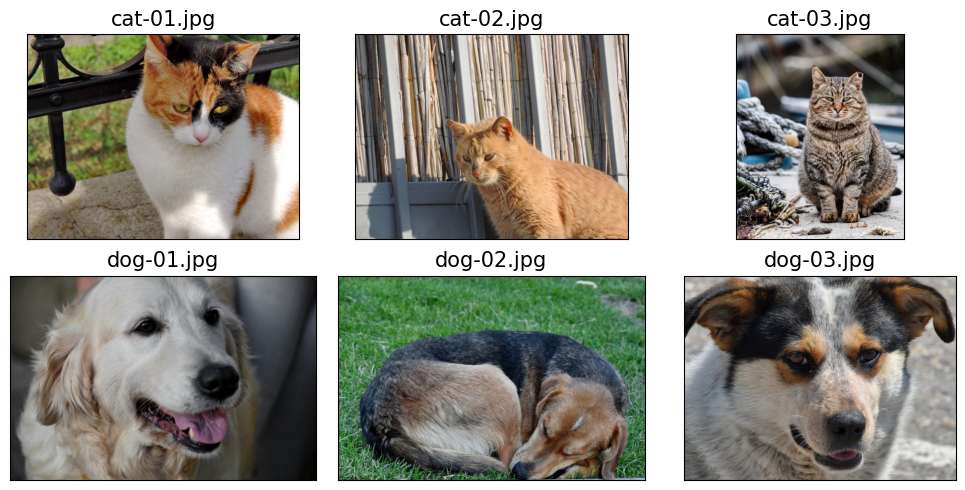

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
  img = Image.open(file)
  print('Размеры изображения:', np.array(img).shape)
  ax = fig.add_subplot(2, 3, i+1)
  ax.set_xticks([]); ax.set_yticks([])
  ax.imshow(img)
  ax.set_title(os.path.basename(file), size=15)
plt.tight_layout()
plt.show()

In [ ]:
labels = [1 if 'dog' in os.path.basename(file) else 0
          for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [ ]:
class ImageDataset(Dataset):
  def __init__(self, file_list, labels, transform=None):
    self.file_list = file_list
    self.labels = labels
    self.transform = transform

  def __getitem__(self, index):
    img = Image.open(self.file_list[index])
    if self.transform is not None:
      img = self.transform(img)
    label = self.labels[index]
    return img, label

  def __len__(self):
    return(len(self.labels))

image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
  print(file, label)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x900 at 0x7CB77FD00250> 0
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x900 at 0x7CB77FC7F110> 0
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=742x900 at 0x7CB77FC7EB50> 0
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x800 at 0x7CB77FC7CDD0> 1
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x800 at 0x7CB77FC7EB50> 1
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x900 at 0x7CB77FC7CDD0> 1


In [11]:
import torchvision.transforms as transforms
img_height, img_width = 80, 120
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])

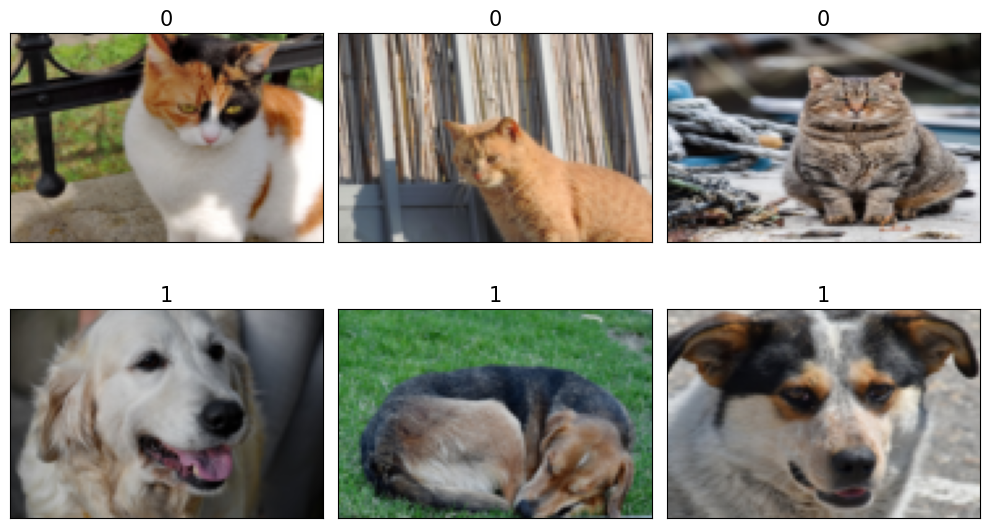

In [ ]:
image_dataset = ImageDataset(file_list, labels, transform)
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
  ax = fig.add_subplot(2, 3, i+1)
  ax.set_xticks([]); ax.set_yticks([])
  ax.imshow(example[0].numpy().transpose((1,2,0)))
  ax.set_title(f'{example[1]}', size=15)

plt.tight_layout()
plt.show()

### Построение модели линейной регрессии


---



In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

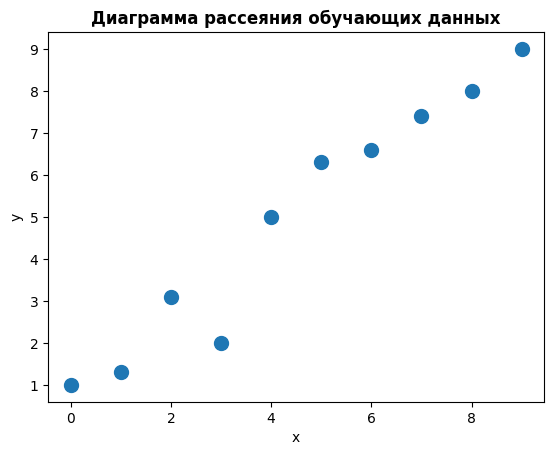

In [ ]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6,
                    7.4, 8.0, 9.0], dtype='float32')
plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title(label='Диаграмма рассеяния обучающих данных', fontweight='bold')
plt.show()

In [12]:
from torch.utils.data import TensorDataset
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train).float()
train_ds = TensorDataset(X_train_norm, y_train)
batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

NameError: name 'X_train' is not defined

In [ ]:
torch.manual_seed(1)
weight = torch.randn(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad=True)
def model(xb):
  return xb @ weight + bias # матричное умножение

def loss_fn(input, target):
  return (input-target).pow(2).mean()

In [ ]:
learning_rate = 0.001
num_epochs = 200
log_epochs = 10
for epoch in range(num_epochs):
  for x_batch, y_batch in train_dl:
    pred = model(x_batch)
    loss = loss_fn(pred, y_batch.long())
    loss.backward()
  with torch.no_grad():
    weight -= weight.grad * learning_rate
    bias -= bias.grad * learning_rate
    weight.grad.zero_()
    bias.grad.zero_()
  if epoch % log_epochs==0:
    print(f'Эпоха {epoch} Потеря {loss.item():.4f}')

Эпоха 0 Потеря 12.2996
Эпоха 10 Потеря 1.1167
Эпоха 20 Потеря 0.3377
Эпоха 30 Потеря 0.2790
Эпоха 40 Потеря 0.5407
Эпоха 50 Потеря 0.7675
Эпоха 60 Потеря 0.7219
Эпоха 70 Потеря 0.3559
Эпоха 80 Потеря 0.0644
Эпоха 90 Потеря 0.3240
Эпоха 100 Потеря 0.0042
Эпоха 110 Потеря 0.1040
Эпоха 120 Потеря 0.0306
Эпоха 130 Потеря 0.5801
Эпоха 140 Потеря 0.0003
Эпоха 150 Потеря 0.0206
Эпоха 160 Потеря 0.5606
Эпоха 170 Потеря 0.0128
Эпоха 180 Потеря 0.0085
Эпоха 190 Потеря 2.0310


In [ ]:
print('Окончательные параметры:', weight.item(), bias.item())

Окончательные параметры: 2.641441583633423 4.799972057342529


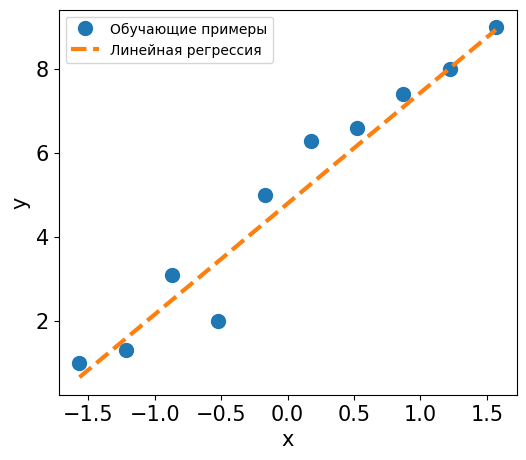

In [ ]:
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Обучающие примеры', 'Линейная регрессия'], fontsize=10)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

### Обучение модели с помощью модулей torch.nn и torch.optim

In [13]:
import torch.nn as nn
loss_fn = nn.MSELoss(reduction='mean')
input_size = 1
output_size = 1
model = nn.Linear(input_size, output_size) # линейный слой
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

NameError: name 'learning_rate' is not defined

In [ ]:
for epoch in range(num_epochs):
  for x_batch, y_batch in train_dl:
    # 1. Генерируем прогнозы
    pred = model(x_batch)[:, 0]
    # 2. Вычисляем потери
    loss = loss_fn(pred, y_batch)
    # 3. Вычисляем градиенты
    loss.backward()
    # 4. Обновляем параметры, используя градиенты
    optimizer.step()
    # 5. Обнуляем градиенты
    optimizer.zero_grad()
  if epoch % log_epochs==0:
    print(f'Эпохи {epoch} Потери {loss.item():.4f}')

Эпохи 0 Потери 8.0616
Эпохи 10 Потери 4.1641
Эпохи 20 Потери 27.4636
Эпохи 30 Потери 1.7707
Эпохи 40 Потери 12.7243
Эпохи 50 Потери 7.5219
Эпохи 60 Потери 2.4434
Эпохи 70 Потери 0.2284
Эпохи 80 Потери 1.4594
Эпохи 90 Потери 1.7836
Эпохи 100 Потери 1.4558
Эпохи 110 Потери 0.2364
Эпохи 120 Потери 1.9793
Эпохи 130 Потери 0.2323
Эпохи 140 Потери 0.6697
Эпохи 150 Потери 0.3107
Эпохи 160 Потери 0.2457
Эпохи 170 Потери 0.0795
Эпохи 180 Потери 0.0892
Эпохи 190 Потери 0.0064


In [ ]:
print('Окончательные параметры:', model.weight.item(), model.bias.item())

Окончательные параметры: 2.663029432296753 4.865717887878418


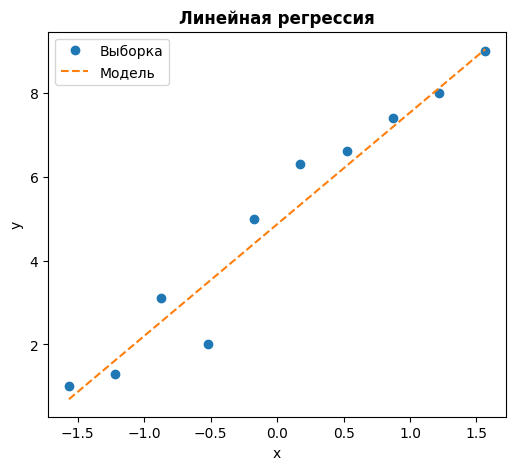

In [ ]:
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o')
plt.plot(X_test_norm, model(X_test_norm).detach().numpy(), '--')
plt.legend(['Выборка', 'Модель'])
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.title(label='Линейная регрессия', fontweight='bold')
plt.show()

### Построение многослойного персептрона для классификации цветков в наборе данных Iris


---



In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
X = iris['data']
y = iris['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1./3, random_state=1
)

In [ ]:
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train)
train_ds = TensorDataset(X_train_norm, y_train)
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
class Model(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)
  def forward(self, x):
    x = self.layer1(x)
    x = nn.Sigmoid() (x)
    x = self.layer2(x)
    return x

input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
model = Model(input_size, hidden_size, output_size)

In [ ]:
learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# обучение
num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs
for epoch in range(num_epochs):
  for x_batch, y_batch in train_dl:
    pred = model(x_batch)
    loss = loss_fn(pred, y_batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    loss_hist[epoch] += loss.item()*y_batch.size(0)
    is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
    accuracy_hist[epoch] += is_correct.sum()
  loss_hist[epoch] /= len(train_dl.dataset)
  accuracy_hist[epoch] /= len(train_dl.dataset)

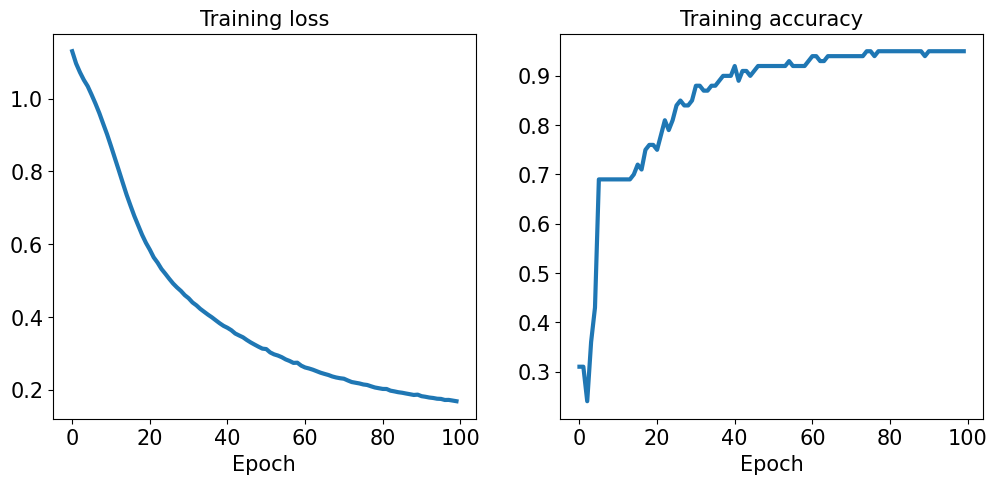

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [ ]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test)
pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Точность на тестовых данных: {accuracy:.4f}')

Точность на тестовых данных: 0.9800


In [ ]:
path = 'iris_classifier.pt'
torch.save(model, path)

In [ ]:
model_new = torch.load(path, weights_only=False)
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

## Выбор функции активации для многослойных нейронных сетей


---



$$ softmax = p(z) = σ(z) = \frac{e^{z_i}}{\sum{e^{z_j}}} $$

In [6]:
W = np.array([[1.1, 1.2, 0.8, 0.4],
              [0.2, 0.4, 1.0, 0.2],
              [0.6, 1.5, 1.2, 0.7]])
A = np.array([[1, 0.1, 0.4, 0.6]]) # веса, где первый столбец массива = 1
# так как в W первая строка - bias
Z = np.dot(W, A[0])

def softmax(z):
  return np.exp(z) / np.sum(np.exp(z))
y_probas = softmax(Z)
print('Вероятности:\n', y_probas)
print(np.sum(y_probas))

Вероятности:
 [0.447 0.161 0.392]
1.0


In [7]:
# пример активации softmax
torch.softmax(torch.from_numpy(Z), dim=0)

tensor([0.4467, 0.1611, 0.3922], dtype=torch.float64)

### Расширение выходного спектра с использованием гиперболического тангенса


---



Другой сигмоидной функцией, которая часть применяется в скрытых слоях является гиперболических тангенс:

$$ σ_{logistic}(z) = \frac{1}{1 + e^{-z}} $$

$$ σ_{tg}(z) = 2 * σ_{logistic}(2z) - 1 = \frac{e^z - e^{-z}}{e^z + e^{-z}} $$

Преимущество гиперболического тангенса перед логистической функцией состоит в том, что он имеет более широкий выходной спектр в открытом интервале (-1, 1), что позволяет улучшить сходимость алгоритма обратного распространения ошибки.

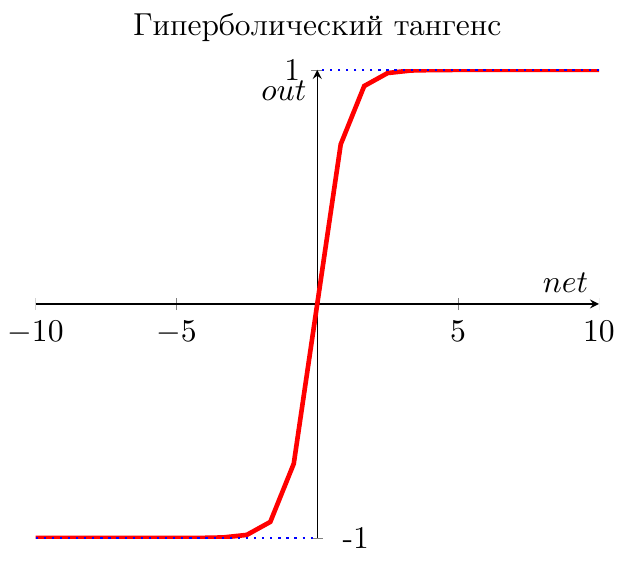

В отличие от гиперболического тангенса, логистическая функция возвращает выходной сигнал в пределах открытого интервала (0, 1).

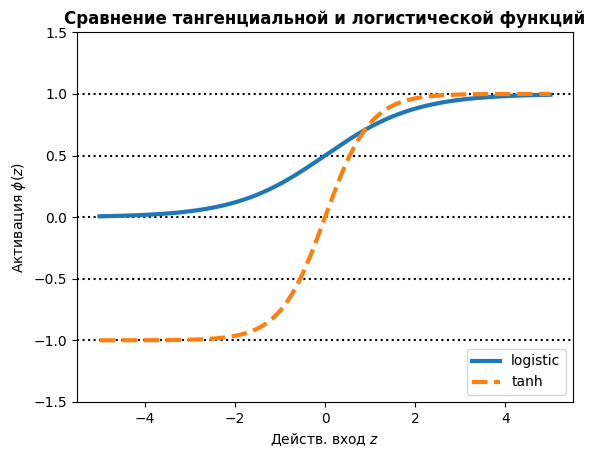

In [19]:
import matplotlib.pyplot as plt

def tanh(z):
  e_p = np.exp(z)
  e_m = np.exp(-z)
  return (e_p - e_m) / (e_p + e_m)

def logistic(z):
    return 1 / (1 + np.exp(-z))

z = np.arange(-5, 5, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)

plt.ylim([-1.5, 1.5])
plt.xlabel('Действ. вход $z$')
plt.ylabel('Активация $\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')

plt.plot(z, log_act,
         linewidth=3,
         label='logistic')
plt.plot(z, tanh_act,
         linewidth=3,
         label='tanh',
         linestyle='--')
plt.legend(loc='lower right')
plt.title(label='Сравнение тангенциальной и логистической функций', fontweight='bold')
plt.show()

По графику видно, что формы кривых похожи, но функция гиперболического тангенса имеет вдвое большее выходное пространство, чем логистическая функция.

In [23]:
# функция tanh
print(np.tanh(z))

from scipy.special import expit
print(expit(z))

print(torch.sigmoid(torch.from_numpy(z)))

[-1. -1. -1. ...  1.  1.  1.]
[0.007 0.007 0.007 ... 0.993 0.993 0.993]
tensor([0.0067, 0.0067, 0.0068,  ..., 0.9932, 0.9932, 0.9933],
       dtype=torch.float64)


### ReLU


---



Rectified Linear Unit (ReLU) - еще одна функция активации, часть используемая в глубоких нейронных сетях.

Рассмотрим проблему затухающего градиента тангенциальной и логистической активаций.

Предположим, что у нас изначально есть действующий вход $z_1 = 20$, который меняется на $z_2 = 25$. Вычисляя активацию tabh мы получаем $σ(z_1) = 1.0$ и $σ(z_2) = 1.0$, что свидетельствует об отсутствии изменений на выходе (из-за исимптотического поведения функции tanh и погрешности вычислений).

Это означает, что производная активаций по действующему входу уменьшается, когда z становиттся большим. В результате обучение весов выполняется очень медленно, поскольку члены градиента близки к нулю. Функция ReLU устраняет эту проблему.

$$ σ(z) = max(0, z) $$

Производная ReLU по входу всегда равна 1 для положительных входных значений. Следовательно, эта функция активации решает проблему исчезающих градиентов, что делает ее хорошим выбором для построения глубоких нейронных сетей.

In [24]:
torch.relu(torch.from_numpy(z))

tensor([0.0000, 0.0000, 0.0000,  ..., 4.9850, 4.9900, 4.9950],
       dtype=torch.float64)

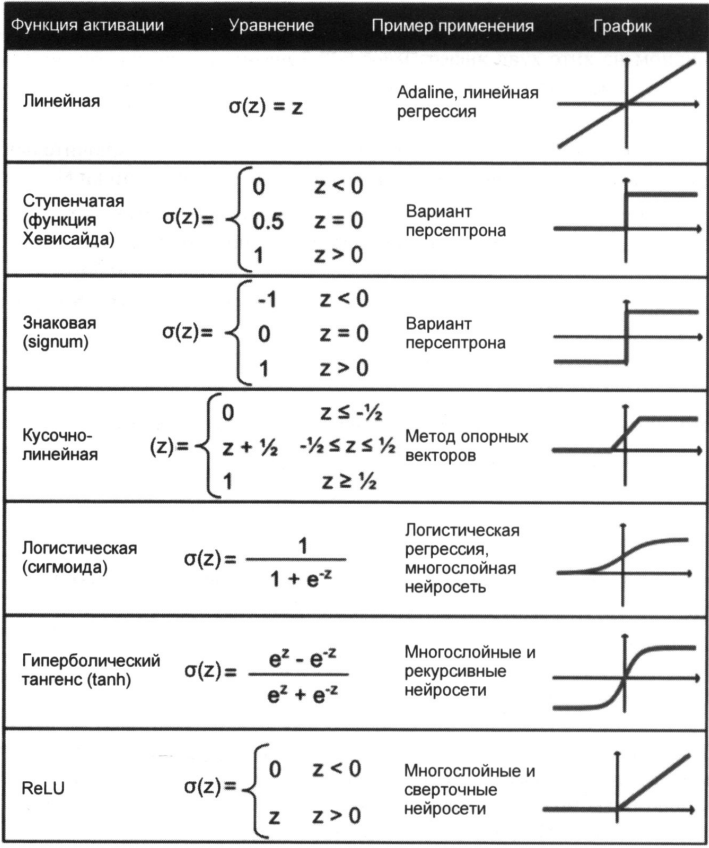